In [43]:
import matplotlib.pyplot as plt
import numpy as np, math
from skimage.io import imread
from skimage.color import rgb2gray
import cv2

def plot_image(image, title=''):
    plt.imshow(image)
    plt.axis('off')
    plt.title(title, size=20)

# DFT

def exp(knN):
    th = -2 * math.pi * knN
    return complex(math.cos(th), math.sin(th))

def dft(g):
    N = len(g)
    dst = [sum(g[n] * exp(-k*n/N ) for n in range(N)) for k in range(N) ]
    return np.array(dst)

def idft(G):
    N = len(G)
    dst = [sum(G[n] * exp(k*n/N) for n in range(N)) for k in range(N) ]
    return np.array(dst) / N

def dft2(image):
    tmp = [dft(row) for row in image]
    dst = [dft(row) for row in np.transpose(tmp)]
    return np.transpose(dst)                   # 전치 환원 후 반환

def idft2(image):
    tmp = [idft(row) for row in image]
    dst = [idft(row) for row in np.transpose(tmp)]
    return np.transpose(dst)                   # 전치 환원 후 반환

def calc_spectrum(complex):
    if complex.ndim == 2: dst = abs(complex)                   # sqrt(re^2 + im^2) 계산해줌
    else: dst = cv2.magnitude(complex[:,:,0], complex[:,:,1])
    dst = 20*np.log(dst+1)
    return cv2.convertScaleAbs(dst)

def fftshift(img):
    dst = np.zeros(img.shape, img.dtype)
    h, w = dst.shape[:2]
    cy, cx = h // 2, w // 2                             # 나누기 하며 소수점 절삭
    dst[h-cy:, w-cx:] = np.copy(img[0:cy , 0:cx ])      # 1사분면 -> 3사분면
    dst[0:cy, 0:cx ] = np.copy(img[h-cy:, w-cx:])       # 3사분면 -> 1사분면
    dst[0:cy, w-cx:] = np.copy(img[h-cy:, 0:cx ])       # 2사분면 -> 4사분면
    dst[h-cy:, 0:cx ] = np.copy(img[0:cy , w-cx:])      # 4사분면 -> 2사분면
    return dst

def ck_time(mode = 0):
    global stime
    if (mode ==0 ):
       stime = time.perf_counter()
    elif (mode==1):
       etime = time.perf_counter()
       print("수행시간 = %.5f sec" % (etime - stime))   #초 단위 경과 시간

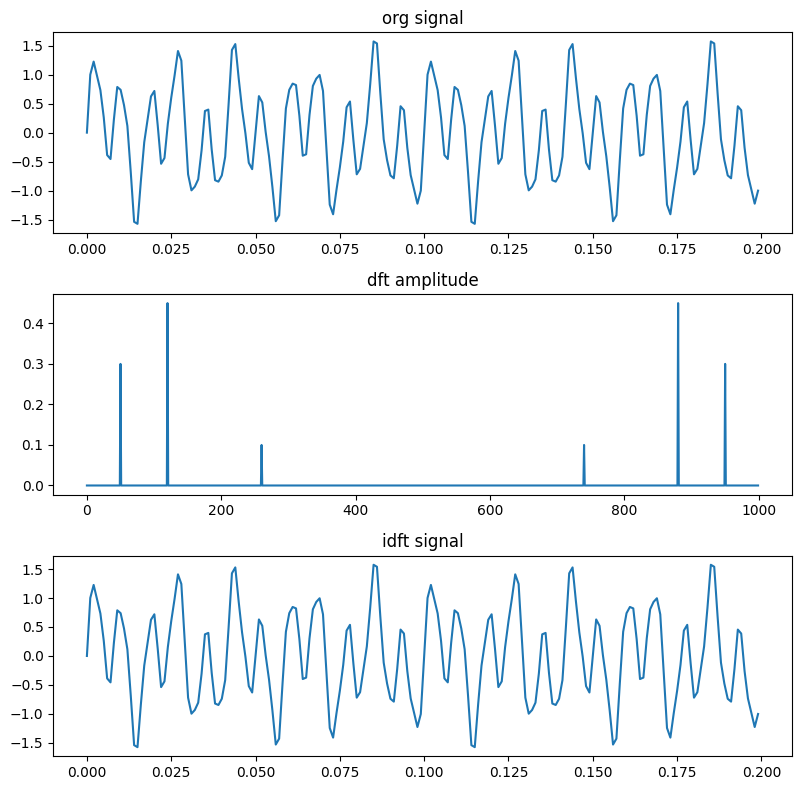

In [ ]:
import numpy as np, math
import matplotlib.pyplot as plt

fmax = 1000      # 샘플링 주파수 1000 Hz: 최대주파수의 2배
dt = 1/fmax      # 샘플링 간격
t = np.arange(0, 1, dt)         # 시간 리스트

g1 = np.sin(2*np.pi*50*t)
g2 = np.sin(2*np.pi*120*t)
g3 = np.sin(2*np.pi*260*t)
g = g1 * 0.6 + g2 * 0.9 + g3 * 0.2          # 신호 합성

N = len(g)                          # 신호 길이
df = fmax/N                         #
f = np.arange(0, N, df)
G = dft(g) * dt                    # 사용자 정의 DFT
g2 = idft(G) / dt

plt.figure(figsize=(8,8))
plt.subplot(3,1,1), plt.plot(t[0:200], g[0:200]), plt.title('org signal')
plt.subplot(3,1,2), plt.plot(f, np.abs(G) ), plt.title('dft amplitude')
plt.subplot(3,1,3), plt.plot(t[0:200], g2[0:200]), plt.title('idft signal')
plt.tight_layout()
plt.show()

수행시간 = 10.99260 sec


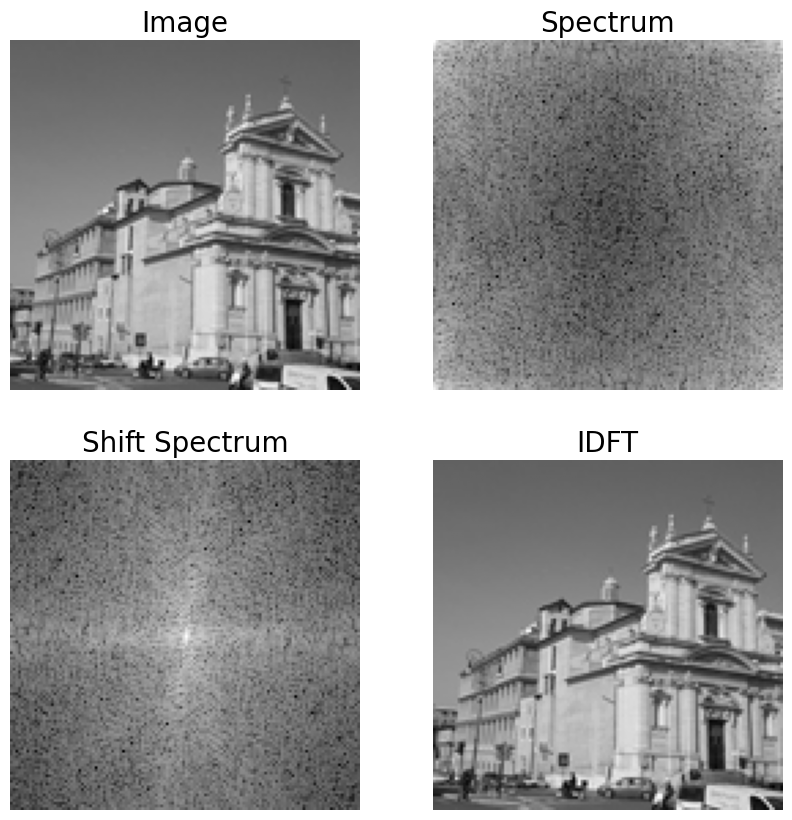

In [ ]:
import numpy as np, math, time
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('build_128.jpg', cv2.IMREAD_GRAYSCALE)
# image = cv2.imread('build_128.jpg', cv2.IMREAD_GRAYSCALE)

ck_time(0)
dft = dft2(image)
spectrum1 = calc_spectrum(dft)
spectrum2 = fftshift(spectrum1)
idft = idft2(dft).real                # 2차원 IDFT 수행
ck_time(1)

plt.figure(figsize=(10,10))
plt.gray()
plt.subplot(221), plot_image(image, 'Image')
plt.subplot(222), plot_image(spectrum1, 'Spectrum')
plt.subplot(223), plot_image(spectrum2, 'Shift Spectrum')
plt.subplot(224), plot_image(cv2.convertScaleAbs(idft), 'IDFT')
plt.show()